In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install lightgbm

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [161]:
# Load dataset
file_path = "/content/drive/MyDrive/Local_Price.csv"
df = pd.read_csv(file_path)

print(f"Shape of df after loading: {df.shape}")
if df.empty:
    print("WARNING: DataFrame is empty immediately after loading the CSV. Please check the CSV file or the file_path.")
else:
    print("Columns:")
    print(df.columns)
    df.head()

Shape of df after loading: (6821, 12)
Columns:
Index(['Date', 'District', 'Black GR-1 (Highest Price)',
       'Black GR-1 (Average Price)', 'Black GR-2 (Highest Price)',
       'Black GR-2 (Average Price)', 'WHITE (Highest Price)',
       'WHITE (Average Price)', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')


In [162]:
# Rename to simple names
df = df.rename(columns={
    'Black GR-1 (Highest Price)': 'black_gr1_high',
    'Black GR-1 (Average Price)': 'black_gr1_avg',
    'Black GR-2 (Highest Price)': 'black_gr2_high',
    'Black GR-2 (Average Price)': 'black_gr2_avg',
    'WHITE (Highest Price)': 'white_high',
    'WHITE (Average Price)': 'white_avg'
})

# Drop unnamed columns
df = df.drop(columns=[c for c in df.columns if 'Unnamed:' in c], errors="ignore")

print("Loaded shape:", df.shape)
print(df.columns)
df.head()

Loaded shape: (6821, 8)
Index(['Date', 'District', 'black_gr1_high', 'black_gr1_avg', 'black_gr2_high',
       'black_gr2_avg', 'white_high', 'white_avg'],
      dtype='object')


,Date,District,black_gr1_high,black_gr1_avg,black_gr2_high,black_gr2_avg,white_high,white_avg
0,5/1/2016,Kandy,"1,250.00","1,208.00","1,180.00","1,144.00","1,800.00","1,725.00"
1,5/1/2016,Matale,"1,275.00","1,253.00",-,-,"1,900.00","1,769.00"
2,5/1/2016,Nuwara Eliya,"1,210.00","1,203.00",-,-,-,-
3,5/1/2016,Kegalle,"1,200.00","1,200.00",-,-,"1,500.00","1,450.00"
4,5/1/2016,Ratnapura,"1,220.00","1,210.00",-,-,-,-


In [164]:
# Clean price columns
price_cols = [
    'black_gr1_high','black_gr1_avg',
    'black_gr2_high','black_gr2_avg',
    'white_high','white_avg'
]

for col in price_cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [165]:
# Extract features
# Try dd/mm/yyyy first
df["Date_temp"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")

# If any failed, try mm/dd/yyyy fallback
mask = df["Date_temp"].isna()
df.loc[mask, "Date_temp"] = pd.to_datetime(df.loc[mask, "Date"], format="%m/%d/%Y", errors="coerce")

df["Date"] = df["Date_temp"]
df.drop(columns=["Date_temp"], inplace=True)

# Remove rows where Date still could not be parsed
df.dropna(subset=["Date"], inplace=True)

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month

# week-of-year (1–53)
df["week"] = df["Date"].dt.isocalendar().week.astype(int)

print("After date parse:", df.shape)

After date parse: (6818, 11)


In [166]:
print("Unique districts before fill:", df["District"].nunique())

for col in price_cols:
    df[col] = df.groupby("District")[col].transform(lambda x: x.fillna(x.mean()))

print("Unique districts after fill:", df["District"].nunique())

Unique districts before fill: 15
Unique districts after fill: 15


In [167]:
data_list = []

for _, row in df.iterrows():
    # Black GR1 + GR2 (use averages)
    data_list.append([row["District"], "Black", "GR1", row["year"], row["month"], row["week"], row["black_gr1_avg"]])
    data_list.append([row["District"], "Black", "GR2", row["year"], row["month"], row["week"], row["black_gr2_avg"]])

    # White (your file has WHITE avg; treat as GR1)
    data_list.append([row["District"], "White", "GR1", row["year"], row["month"], row["week"], row["white_avg"]])

new_df = pd.DataFrame(
    data_list,
    columns=["district", "pepper_type", "grade", "year", "month", "week", "price"]
)

# Drop rows where price is missing
new_df.dropna(subset=["price"], inplace=True)

print("new_df shape:", new_df.shape)
print("Unique districts:", new_df["district"].nunique())
print("Unique pepper types:", new_df["pepper_type"].unique())
print("Unique grades:", new_df["grade"].unique())
new_df.head()

new_df shape: (15096, 7)
Unique districts: 15
Unique pepper types: ['Black' 'White']
Unique grades: ['GR1' 'GR2']


,district,pepper_type,grade,year,month,week,price
0,Kandy,Black,GR1,2016,1,1,1208.000000
1,Kandy,Black,GR2,2016,1,1,1144.000000
2,Kandy,White,GR1,2016,1,1,1725.000000
3,Matale,Black,GR1,2016,1,1,1253.000000
4,Matale,Black,GR2,2016,1,1,592.636364


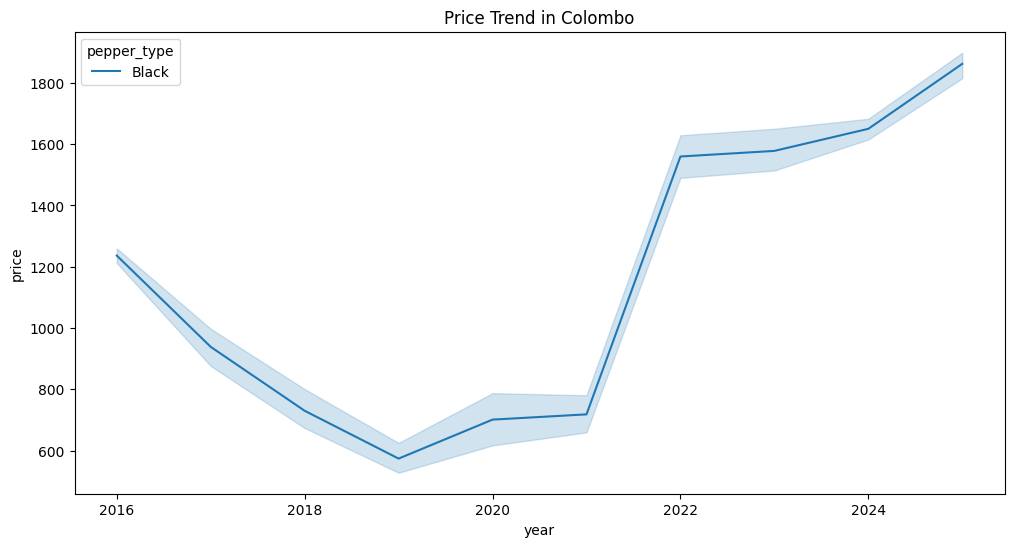

In [169]:
# Sample visualization
district_name = "Colombo"
temp = new_df[new_df["district"] == district_name].copy()

plt.figure(figsize=(12,6))
sns.lineplot(data=temp, x="year", y="price", hue="pepper_type")
plt.title(f"Price Trend in {district_name}")
plt.show()

In [170]:
# Encoding and training
le_district = LabelEncoder()
le_type = LabelEncoder()
le_grade = LabelEncoder()

new_df["district"] = le_district.fit_transform(new_df["district"])
new_df["pepper_type"] = le_type.fit_transform(new_df["pepper_type"])
new_df["grade"] = le_grade.fit_transform(new_df["grade"])

X = new_df[["district", "pepper_type", "grade", "year", "month", "week"]]
y = new_df["price"]

# time-aware split (no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

params = {
    "num_leaves": [31, 50],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 300]
}

model = lgb.LGBMRegressor()
grid = GridSearchCV(model, params, cv=3, scoring="r2")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 92
[LightGBM] [Info] Number of data points in the train set: 8050, number of used features: 6
[LightGBM] [Info] Start training from score 1096.856523
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 91
[LightGBM] [Info] Number of data points in the train set: 8051, number of used features: 6
[LightGBM] [Info] Start training from score 1242.111211
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

In [171]:
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 79284.29545753819
RMSE: 281.57467119316357
MAE: 191.10274464114707
R2: 0.8273731469953507


In [172]:
joblib.dump(best_model, "pepper_price_model.pkl")
joblib.dump(le_district, "district_encoder.pkl")
joblib.dump(le_type, "type_encoder.pkl")
joblib.dump(le_grade, "grade_encoder.pkl")

print("Saved: pepper_price_model.pkl + 3 encoders")

Saved: pepper_price_model.pkl + 3 encoders
